# In development!

Status:
- we can reproduce Adam's energy for the 4x4 "tilted" Lieb lattice (2 Cu per unit cell)!!

In [ ]:
from pathlib import Path

from tutorial_utils import run_afqmc, get_scratch_dir

home = Path.home()
scratch_dir = get_scratch_dir("ex_emery_model",home/".scratch")

## Set up the lattice

computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors


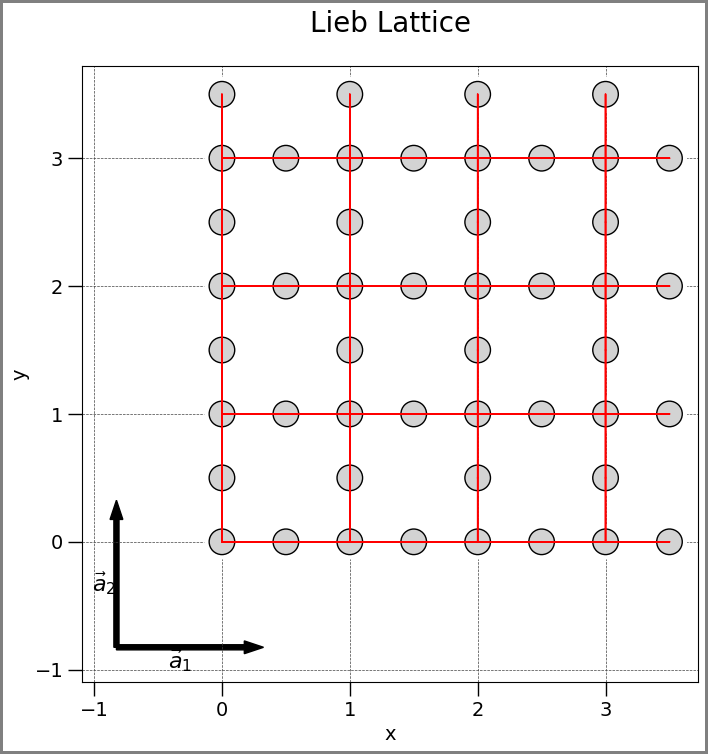

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Lieb Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
from afqmctools.systems.lattice import get_lattice
import afqmctools.utils.visualize as vis

lattice_params = dict(
    L1 = 4,
    L2 = 4,
    type = 'square',
    basis = [
        [0.,0.],    # Cu 3d_{x^2 - y^2}
        [0.5,0.0],  # O 2p_x
        [0.0,0.5]   # O 2p_y
    ]
)

lattice = get_lattice(
    params=lattice_params
)

vis.plot_lattice(lattice,title="Lieb Lattice",show_labels=False)

## Set up the Hamiltonian

In [ ]:
import numpy as np

# definning model parameters
tdp = 1.2
tpp = 0.7
epsilon_d = -7.6
epsilon_p = -3.2
Ud = 8.4
Up = 2.0

# for the Emery model, we have to define sign conventions related to the
#   overlap of the +/- lobes of the Co 3d_{x^2 - y^2} orbital and the O 2p_x / 2p_y orbitals
#
#   For tpd:
#       we'll use a '+' sign for the -x, +y direction
#       we'll use a '-' sign for the +x, -y direction
#   For tpp:
#       we'll use a '+' sign for the 1/sqrt(2) (-x, +y), and 1/sqrt(2) (+x,-y) direction
#       we'll use a '-' sign for the 1/sqrt(2) (-x, -y), and 1/sqrt(2) (+x,+y) direction

# define unit vectors
x_hat = np.array([1.0,0.0])
y_hat = np.array([0.0,1.0])

r_x_minus_y_hat = (1/np.sqrt(2))*np.array([1.0,-1.0])  # \hat{r}_{x-y} = \hat{x} - \hat{y}
r_xy_hat = (1/np.sqrt(2))*np.array([1.0,1.0])         # \hat{r}_{x+y} = \hat{x} + \hat{y}

t_pd_signs = { () }

# TODO: make the hopping matrix taking care of the +/- sign
hopping_shape = (lattice.N_sites, lattice.N_sites)

hopping = np.zeros(hopping_shape,dtype=np.complex128)

for pair in lattice.get_nth_neighbors(n=1):
    i,j = pair.i,pair.j
    if j <= i:
        continue

    if np.dot(pair.r_relative,x_hat) > 0 or np.dot(pair.r_relative,-y_hat) > 0:
        hopping[i,j] = -tdp
    elif np.dot(pair.r_relative,-x_hat) > 0 or np.dot(pair.r_relative,y_hat) > 0:
        hopping[i,j] = tdp
    else:
        raise ValueError(f"Unexpected relative distance for nearest neighbors. {pair.r_relative}")

for pair in lattice.get_nth_neighbors(n=2):
    i,j = pair.i,pair.j
    if j <= i:
        continue

    if np.dot(pair.r_relative,r_x_minus_y_hat) != 0.0:
        hopping[i,j] = tpp
    elif np.dot(pair.r_relative,r_xy_hat) != 0.0:
        hopping[i,j] = -tpp
    else:
        raise ValueError(f"Unexpected relative distance for next-nearest neighbors. {pair.r_relative}")

# add in the j<=i part of the hopping matrix
hopping = hopping + hopping.T.conj()


# add in on-site energies
U_emery = np.zeros((lattice.N_sites),dtype=np.complex128)
for i in range(lattice.N_sites):
    if i % 3 == 0:
        hopping[i,i] = epsilon_d
        U_emery[i] = Ud
    elif i % 3 == 1 or i % 3 == 2:
        hopping[i,i] = epsilon_p
        U_emery[i] = Up

computing and storing 2th-nearest neighbors
computing and storing 2th-nearest image neighbors


In [ ]:
from afqmctools.hamiltonian.model.director import HamiltonianDirector
import afqmctools.utils.io as io

hamiltonian_params = {
    'hamiltonian' : dict(
        t = 0.0,
        U = U_emery,
        custom_one_body = hopping,
    )
}

hamiltonian = HamiltonianDirector(
    lattice=lattice,
    source=hamiltonian_params
).build()

io.write_model_hamiltonian(
    hamiltonian=hamiltonian,
    fname=scratch_dir/"afqmc.h5"
)

running build step nth_neighbor_hopping((0.0,))
running build step custom_one_body((array([[-7.6+0.j, -1.2+0.j,  1.2+0.j, ...,  0. +0.j,  0. +0.j,  0. +0.j],
       [-1.2+0.j, -3.2+0.j,  0.7+0.j, ...,  0. +0.j,  0. +0.j,  0. +0.j],
       [ 1.2+0.j,  0.7+0.j, -3.2+0.j, ...,  0. +0.j,  0. +0.j,  0. +0.j],
       ...,
       [ 0. +0.j,  0. +0.j,  0. +0.j, ..., -7.6+0.j, -1.2+0.j,  1.2+0.j],
       [ 0. +0.j,  0. +0.j,  0. +0.j, ..., -1.2+0.j, -3.2+0.j,  0.7+0.j],
       [ 0. +0.j,  0. +0.j,  0. +0.j, ...,  1.2+0.j,  0.7+0.j, -3.2+0.j]],
      shape=(48, 48)),))
running build step onsite_hubbard((array([8.4+0.j, 2. +0.j, 2. +0.j, 8.4+0.j, 2. +0.j, 2. +0.j, 8.4+0.j,
       2. +0.j, 2. +0.j, 8.4+0.j, 2. +0.j, 2. +0.j, 8.4+0.j, 2. +0.j,
       2. +0.j, 8.4+0.j, 2. +0.j, 2. +0.j, 8.4+0.j, 2. +0.j, 2. +0.j,
       8.4+0.j, 2. +0.j, 2. +0.j, 8.4+0.j, 2. +0.j, 2. +0.j, 8.4+0.j,
       2. +0.j, 2. +0.j, 8.4+0.j, 2. +0.j, 2. +0.j, 8.4+0.j, 2. +0.j,
       2. +0.j, 8.4+0.j, 2. +0.j, 2. +0.j, 8.4+0.

## Run Hartree-Fock (HF)

(somtimes jax doesn't initialize properly on the first run; just try running again!)

In [ ]:
import jax
jax.config.update('jax_platform_name', 'cpu')

from autohf import lattice_hf, AutoHFHamiltonian

from afqmctools.inputs.from_autohf import autohf_to_afqmc

nelec = (8,8)

hf_settings = dict(
    ansatz = 'SD',
    numSteps = 400,
    nelec = nelec,
    numTrials = 20,
    seed = 42,
    measure_spin = True,
    noncollinear = True
)

results = lattice_hf(
    hamiltonian=AutoHFHamiltonian(hamiltonian),
    settings=hf_settings
)

autohf_to_afqmc(
    results,
    output_fname = scratch_dir/"ghf_wfn.h5"
)


Reading hopping from spin sector 0
Reading hopping from spin sector 1
Added unique T terms: [array([-7.6+0.j, -3.2+0.j, -1.2+0.j, -0.7+0.j,  0.7+0.j,  1.2+0.j]), array([-7.6+0.j, -3.2+0.j, -1.2+0.j, -0.7+0.j,  0.7+0.j,  1.2+0.j])]
Added unique U terms: [2.  8.4]

    -----------------------
    - ╔═╗ ------- ╖ ╓╔═╕ --
    - ╠═╣ ╖╖╒╦╕╔╗ ╠═╣╠╕ ---
    - ╜ ╙ ╚╝ ╜ ╚╝ ╜ ╙╨ ----
    -----------------------
    
"numSteps" is deprecated, please use "steps" instead
"numTrials" is deprecated, please use "batch_size" instead

 ===== AutoHF Settings ===== 

        noncollinear                                             True
        gpu                                                     False
        approx_expm                                             False
        force_complex                                           False
        ansatz                                                 SD_ROT
        opt_method                                              lbfgs
        riemannian         

/mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/jax/_src/lax/lax.py:3480: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)


Initial Energy: [-77.31945195 -77.48776202 -77.42101548 -77.38757502 -77.42617518
 -77.42914283 -77.40148468 -77.45731661 -77.42835242 -77.31836363
 -77.46542225 -77.50027919 -77.39623683 -77.39803937 -77.50391255
 -77.46289562 -77.50823827 -77.39031135 -77.32460093 -77.40461269]
# iterations: [400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400] frac of possible: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Final energy: -137.35758385764566 [-137.35493937 -137.35590283 -137.35656338 -137.35510901 -137.3562924
 -137.35642819 -137.35646815 -137.35615295 -137.35541996 -137.35662717
 -137.35637166 -137.35662057 -137.35604183 -137.35564757 -137.35500253
 -137.35734508 -137.35758386 -137.30106362 -137.3550522  -137.35498256]


/tmp/ipykernel_326954/3791246282.py:20: RuntimeWarning: The best variational state did not converge in 400 steps. Inspect result carefully!
  results = lattice_hf(


Variational energy of final HF state: -137.35758385764566
<Sz> (0.03166330538830309+7.115076756936123e-20j) <S^2> 7.737712729917892
Wavefunction normalization (noncollinear): (0.9999999999999953+7.767388343116637e-48j)


##  Analyze the HF results
--------------------------

Before proceeding, it's imporant to check that the HF solution is correct.
First, check that AutoHF actually converged.

We will also want to check the charge and spin density on the lattice.
You can you the lattice model visualizer `
vis.plot_lattice(lattice,title="Lieb Lattice",density=...)` to plot an abtritrary density
on the lattice.

Integrated charge: 16.000000000000004
 mean charge density: 0.33333333333333337 +/- 0.35641814333676375
 mean spin density: 0.000659652195589636 +/- 0.1365990691196138
For Cu sublattice: mean charge density: 0.836645792394916 +/- 0.012622191052244713
For O px sublattice: mean charge density: 0.0816873130939016 +/- 0.02187639339906512
For O py sublattice: mean charge density: 0.08166689451118242 +/- 0.02187772898137081


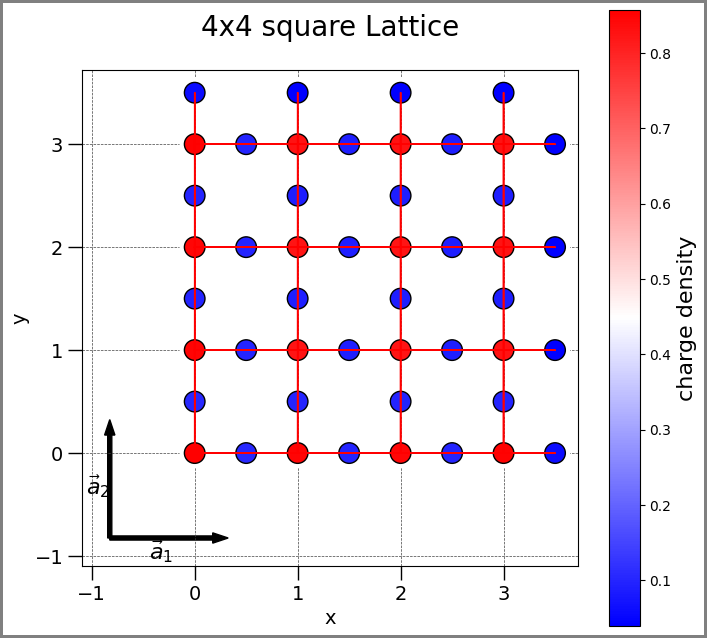

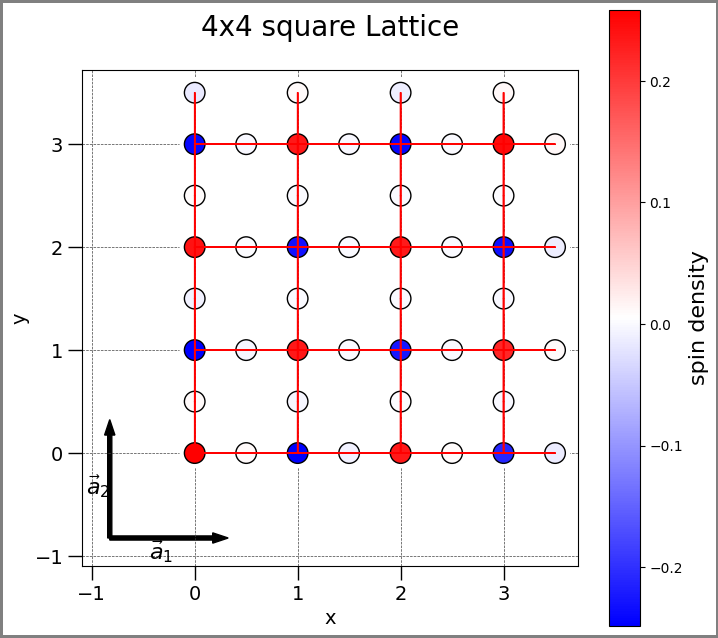

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': '4x4 square Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
import jax.numpy as jnp

# now look at the density
autohf_results = results[0]
autohf_funcs = results[1]
makeRDMs = autohf_funcs['makeRDMs']
state = autohf_results['state']
rdm = makeRDMs(state)

L = lattice.L
# noncollinear
M = lattice.N_sites
new_shape = (L[0],L[1],lattice.nb)
rho_up = rdm[:M,:M].diagonal().reshape(new_shape)
rho_down = rdm[M:,M:].diagonal().reshape(new_shape)

rho_charge = rho_up + rho_down
rho_spin = 0.5*(rho_up - rho_down)

print(f"Integrated charge: {rho_charge.real.sum()}")
print(f" mean charge density: {rho_charge.real.mean()} +/- {np.std(rho_charge.real)}")
print(f" mean spin density: {rho_spin.real.mean()} +/- {np.std(rho_spin.real)}")

Cu_inds =  jnp.array([i*lattice.nb for i in range(lattice.N_sites//lattice.nb)])
Opx_inds = jnp.array([i*lattice.nb+1 for i in range(lattice.N_sites//lattice.nb)])
Opy_inds = jnp.array([i*lattice.nb+2 for i in range(lattice.N_sites//lattice.nb)])

Cu_density_up = rdm[:M,:M].diagonal()[Cu_inds]
Opx_density_up = rdm[:M,:M].diagonal()[Opx_inds]
Opy_density_up = rdm[:M,:M].diagonal()[Opy_inds]

Cu_density_down  = rdm[M:,M:].diagonal()[Cu_inds]
Opx_density_down = rdm[M:,M:].diagonal()[Opx_inds]
Opy_density_down = rdm[M:,M:].diagonal()[Opy_inds]

Cu_density = Cu_density_up + Cu_density_down
Opx_density = Opx_density_up + Opx_density_down
Opy_density = Opy_density_up + Opy_density_down

print(f"For Cu sublattice: mean charge density: {np.mean(Cu_density.real)} +/- {np.std(Cu_density.real)}")
print(f"For O px sublattice: mean charge density: {np.mean(Opx_density.real)} +/- {np.std(Opx_density.real)}")
print(f"For O py sublattice: mean charge density: {np.mean(Opy_density.real)} +/- {np.std(Opy_density.real)}")


vis.plot_lattice(
    lattice,
    density=rho_charge.real,
    density_label="charge density",
    cmap = 'bwr',
    show_labels=False
)

vis.plot_lattice(
    lattice,
    density=rho_spin.real,
    density_label="spin density",
    cmap = 'bwr',
    show_labels=False
)



## 🚧 Old Scratch work below!! 🚧

In [ ]:
import numpy as np

from afqmctools.hamiltonian.model.director import HamiltonianDirector
import afqmctools.utils.io as io
from afqmctools.wavefunction.free_electron import free_electron
from afqmctools.inputs.from_hdf import write_json
import afqmctools.utils.visualize as vis


# define the problem
nelec = (5,5)
nbands = 3

#t_dd = 1.0
t_pd = t = 1.0
t_pp = tprime = 0.5

lattice_params = dict(
    L1 = 4,
    L2 = 4,
    boundary1 = 'PBC',
    boundary2 = 'PBC'
)

lattice = get_lattice(
    params=lattice_params
)

nearest_neighbors = lattice.get_nth_neighbors(n=1)
sites = lattice.sites

nbasis = nbands*lattice.N_sites

hopping_intrasite = np.array([
    [0.0,   t_pd,  t_pd],
    [t_pd,   0.0,  t_pp],
    [t_pd,  t_pp,   0.0]
])

hopping_neatest_x =  np.array([
    [0.0,   t_pd,  0.0],
    [t_pd,   0.0,  t_pp],
    [0.0,  t_pp,   0.0]
])

hopping_neatest_y =  np.array([
    [0.0,    0.0,  t_pd],
    [0.0,   0.0,  t_pp],
    [t_pd,  t_pp,   0.0]
])

hopping = np.zeros((nbasis,nbasis))

# add in intrasite
for site in sites:
    site_slice = slice(site.index*nbands,(site.index+1)*nbands)
    hopping[ site_slice, site_slice ] = hopping_intrasite

# add in nearest-neighbor
for pair in nearest_neighbors:
    i_slice = slice(pair.i*nbands, (pair.i+1)*nbands)
    j_slice = slice(pair.j*nbands, (pair.j+1)*nbands)

    # hopping from Cu to O px/py bands is direction-dependent!
    if (pair.r_relative[0] == 1.0 or pair.r_relative[0] == -1.0):
        hopping[i_slice,j_slice] = hopping_neatest_x
    elif (pair.r_relative[1] == 1.0 or pair.r_relative[1] == -1.0):
        hopping[i_slice,j_slice] = hopping_neatest_y
    else:
        raise ValueError(f"Invalid relative position {pair.r_relative} for a square lattice")


In [ ]:
import matplotlib.pyplot as plt

plt.matshow(hopping)
plt.colorbar()

In [ ]:
hamiltonian_params = {
    'hamiltonian' : dict(
        nbands = nbands,
        t = hopping,
        U = 8.0
    )
}

hamiltonian = HamiltonianDirector(
    lattice=lattice,e
    source=hamiltonian_params
).build()

io.write_model_hamiltion(
    hamiltonian=hamiltonian,
    fname=scratch_dir/"lieb.h5",
    nelec=nelec
)

# Tilted Lieb Lattice : Annealing
---------------------------------

JAX devices :  [CudaDevice(id=0)]
 ==== Emery model run parameters ==== 
   - hole doping, h = 0.125
   - nelectrons = (18, 18)
computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors


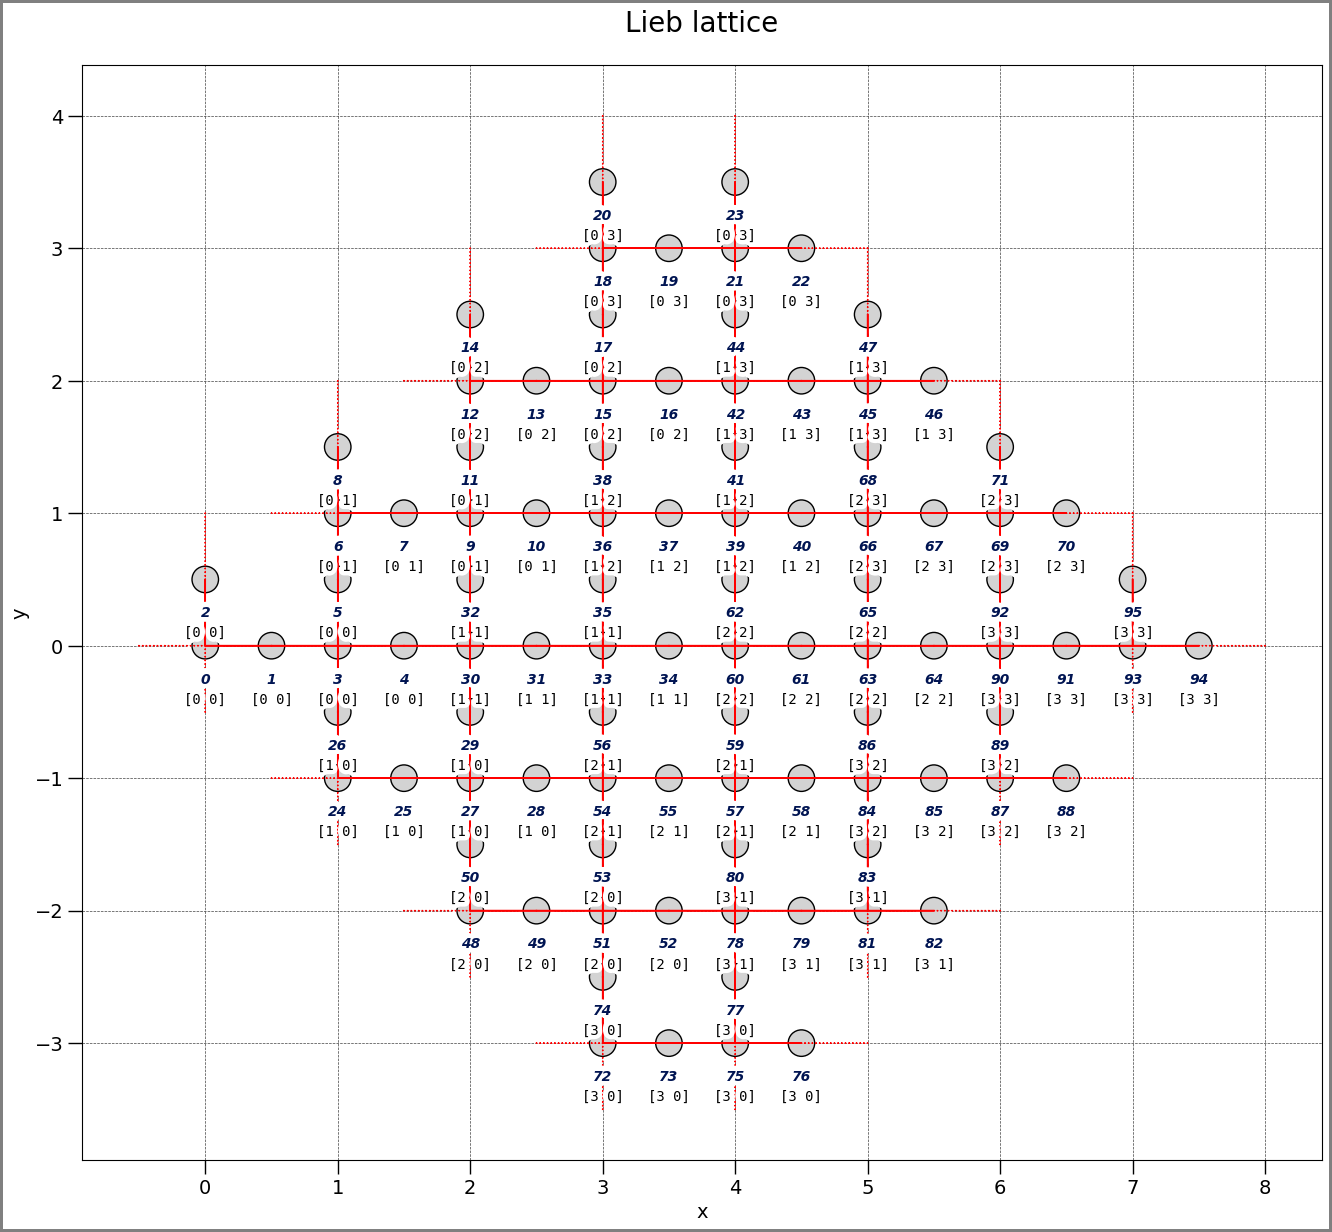

computing and storing 2th-nearest neighbors
computing and storing 2th-nearest image neighbors
[DEBUG] i = 1, j = 2, r_relative = [-0.5  0.5]
[DEBUG] i = 1, j = 5, r_relative = [0.5 0.5]
[DEBUG] i = 1, j = 26, r_relative = [ 0.5 -0.5]
[DEBUG] i = 4, j = 5, r_relative = [-0.5  0.5]
[DEBUG] i = 4, j = 26, r_relative = [-0.5 -0.5]
[DEBUG] i = 4, j = 29, r_relative = [ 0.5 -0.5]
[DEBUG] i = 4, j = 32, r_relative = [0.5 0.5]
[DEBUG] i = 5, j = 7, r_relative = [0.5 0.5]
[DEBUG] i = 7, j = 8, r_relative = [-0.5  0.5]
[DEBUG] i = 7, j = 11, r_relative = [0.5 0.5]
[DEBUG] i = 7, j = 32, r_relative = [ 0.5 -0.5]
[DEBUG] i = 10, j = 11, r_relative = [-0.5  0.5]
[DEBUG] i = 10, j = 32, r_relative = [-0.5 -0.5]
[DEBUG] i = 10, j = 35, r_relative = [ 0.5 -0.5]
[DEBUG] i = 10, j = 38, r_relative = [0.5 0.5]
[DEBUG] i = 11, j = 13, r_relative = [0.5 0.5]
[DEBUG] i = 13, j = 14, r_relative = [-0.5  0.5]
[DEBUG] i = 13, j = 17, r_relative = [0.5 0.5]
[DEBUG] i = 13, j = 38, r_relative = [ 0.5 -0.5]
[DEBU

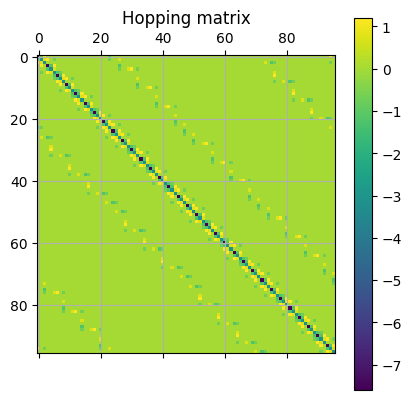

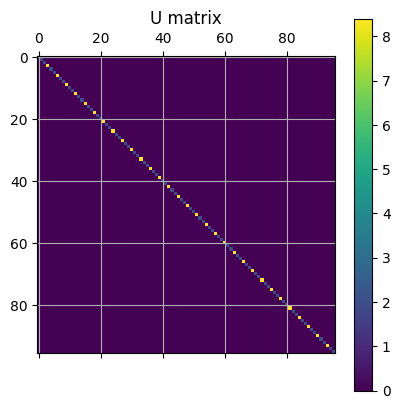

Combining terms of the same type
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  3
computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors
computing and storing 2th-nearest neighbors
computing and storing 2th-nearest image neighbors
[DEBUG] i = 1, j = 2, r_relative = [-0.5  0.5]
[DEBUG] i = 1, j = 5, r_relative = [0.5 0.5]
[DEBUG] i = 1, j = 26, r_relative = [ 0.5 -0.5]
[DEBUG] i = 4, j = 5, r_relative = [-0.5  0.5]
[DEBUG] i = 4, j = 26, r_relative = [-0.5 -0.5]
[DEBUG] i = 4, j = 29, r_relative = [ 0.5 -0.5]
[DEBUG] i = 4, j = 32, r_relative = [0.5 0.5]
[DEBUG] i = 5, j = 7, r_relative = [0.5 0.5]
[DEBUG] i = 7, j = 8, r_relative = [-0.5  0.5]
[DEBUG] i = 7, j = 11, r_relative = [0.5 0.5]
[DEBUG] i = 7, j = 32, r_relative = [ 0.5 -0.5]
[DEBUG] i = 10, j = 11, r_relative = [-0.5  0.5]
[DEBUG] i = 10, j = 32, r_relative = [-0.5 -0.5]
[DEBUG] 

/mnt/home/beskridge/software/SAFIRE_dev/utils/afqmctools/wavefunction/free_electron.py:126: UserWarning: Twist angle of the Hamiltonian does not match the twist angle provided to the free electron wavefunction builder. Using the twist angle from the Hamiltonian.
  warn(
/mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/jax/_src/array.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(self._value, dtype=dtype, **kwds)


energyCall: Etotal=-275.7356759721758 with EK=-329.8778946107393 EU=54.142218638563506 EU1=0 EU2=0 EJ=0 Eheisenber=0
Reference HF Energy = -275.7356759721758
<Sz> 0.0 <S^2> 0.0
Annealing step 0
Reading hopping from spin sector 0
Added unique T terms: [array([-7.6, -3.2, -1.2, -0.7,  0.7,  1.2])]
Added unique U terms: [2.  8.4]

    -----------------------
    - ╔═╗ ------- ╖ ╓╔═╕ --
    - ╠═╣ ╖╖╒╦╕╔╗ ╠═╣╠╕ ---
    - ╜ ╙ ╚╝ ╜ ╚╝ ╜ ╙╨ ----
    -----------------------
    

 ===== AutoHF Settings ===== 

        noncollinear                                             True
        gpu                                                     False
        approx_expm                                             False
        force_complex                                           False
        ansatz                                                     SD
        opt_method                                              lbfgs
        riemannian                                              False
   

/mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/jax/_src/array.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(self._value, dtype=dtype, **kwds)


Reference HF Energy = -273.4680436092519
Initial Energy: [-273.42564514 -273.47071963 -273.45241151 -273.42390376 -273.45909228
 -273.47570737 -273.41345886 -273.4578708  -273.45286569 -273.43987864
 -273.42041613 -273.39920825 -273.48299521 -273.43299184 -273.43131709
 -273.46107829 -273.43788748 -273.45046098 -273.44584576 -273.44252921]
# iterations: [500 500 500 447 500 485 469 500 500 420 400 500 500 500 500 500 500 500
 447 500] frac of possible: [1.    1.    1.    0.894 1.    0.97  0.938 1.    1.    0.84  0.8   1.
 1.    1.    1.    1.    1.    1.    0.894 1.   ]
Final energy: -313.8180220551407 [-313.69302772 -313.67665514 -313.66813165 -313.69302772 -313.73321906
 -313.69302772 -313.69302772 -313.81802206 -313.68100102 -313.69302772
 -313.69302772 -313.69302772 -313.70385526 -313.66813165 -313.81802189
 -313.73321906 -313.66813165 -313.69302772 -313.81802206 -313.81802206]


...

Reference HF Energy = -310.33548995669133
Initial Energy: [-310.31274907 -310.30689895 -310.28854642 -310.32079235 -310.30494093
 -310.31305924 -310.30386302 -310.30554462 -310.32171228 -310.30727424
 -310.32051663 -310.30385594 -310.2954123  -310.29284952 -310.28278286
 -310.29443561 -310.31746838 -310.31044607 -310.30066703 -310.29413509]
# iterations: [137 136 139 143 132 140 140 142 133 144 141 141 145 132 132 143 147 140
 142 133] frac of possible: [0.274 0.272 0.278 0.286 0.264 0.28  0.28  0.284 0.266 0.288 0.282 0.282
 0.29  0.264 0.264 0.286 0.294 0.28  0.284 0.266]
Final energy: -313.8180220551408 [-313.81802206 -313.81802206 -313.81802206 -313.81802206 -313.81802206
 -313.81802206 -313.81802206 -313.81802206 -313.81802206 -313.81802206
 -313.81802206 -313.81802206 -313.81802206 -313.81802206 -313.81802206
 -313.81802206 -313.81802206 -313.81802206 -313.81802206 -313.81802206]
Variational energy of final HF state: -313.8180220551408
Annealing step 8
Reading hopping from spin s

/mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/jax/_src/array.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(self._value, dtype=dtype, **kwds)


Reference HF Energy = -310.4124054082266
Initial Energy: [-310.38330763 -310.35886565 -310.37461817 -310.38805903 -310.38724909
 -310.38977334 -310.36835394 -310.37223949 -310.38468139 -310.37987083
 -310.36858074 -310.37560614 -310.38978136 -310.39445679 -310.36978039
 -310.38183936 -310.38198104 -310.39546995 -310.39637164 -310.36339281]
# iterations: [150 136 141 148 142 137 149 150 140 151 148 145 150 141 148 147 142 141
 139 146] frac of possible: [0.3   0.272 0.282 0.296 0.284 0.274 0.298 0.3   0.28  0.302 0.296 0.29
 0.3   0.282 0.296 0.294 0.284 0.282 0.278 0.292]
Final energy: -313.81802205514083 [-313.81802206 -313.81802206 -313.81802206 -313.81802206 -313.81802206
 -313.81802206 -313.81802206 -313.81802206 -313.81802206 -313.81802206
 -313.81802206 -313.81802206 -313.81802206 -313.81802206 -313.81802206
 -313.81802206 -313.81802206 -313.81802206 -313.81802206 -313.81802206]
Variational energy of final HF state: -313.81802205514083
Found a better energy:  -313.81802205514083


/mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/jax/_src/array.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(self._value, dtype=dtype, **kwds)


Reference HF Energy = -310.3241047527576
Initial Energy: [-310.28101728 -310.29123155 -310.28297118 -310.29734945 -310.30225233
 -310.27967749 -310.30578346 -310.29258795 -310.27420404 -310.29548888
 -310.2850475  -310.279165   -310.29605336 -310.28273512 -310.28670635
 -310.3066993  -310.28574748 -310.29699423 -310.2849333  -310.27544363]
# iterations: [145 141 134 134 140 139 135 130 145 135 143 146 131 130 140 138 136 135
 145 142] frac of possible: [0.29  0.282 0.268 0.268 0.28  0.278 0.27  0.26  0.29  0.27  0.286 0.292
 0.262 0.26  0.28  0.276 0.272 0.27  0.29  0.284]
Final energy: -313.81802205514083 [-313.81802206 -313.81802206 -313.81802206 -313.81802206 -313.81802206
 -313.81802206 -313.81802206 -313.81802206 -313.81802206 -313.81802206
 -313.81802206 -313.81802206 -313.81802206 -313.81802206 -313.81802206
 -313.81802206 -313.81802206 -313.81802206 -313.81802206 -313.81802206]
Variational energy of final HF state: -313.8180220551408
Integrated charge: 36.0
 mean charge density

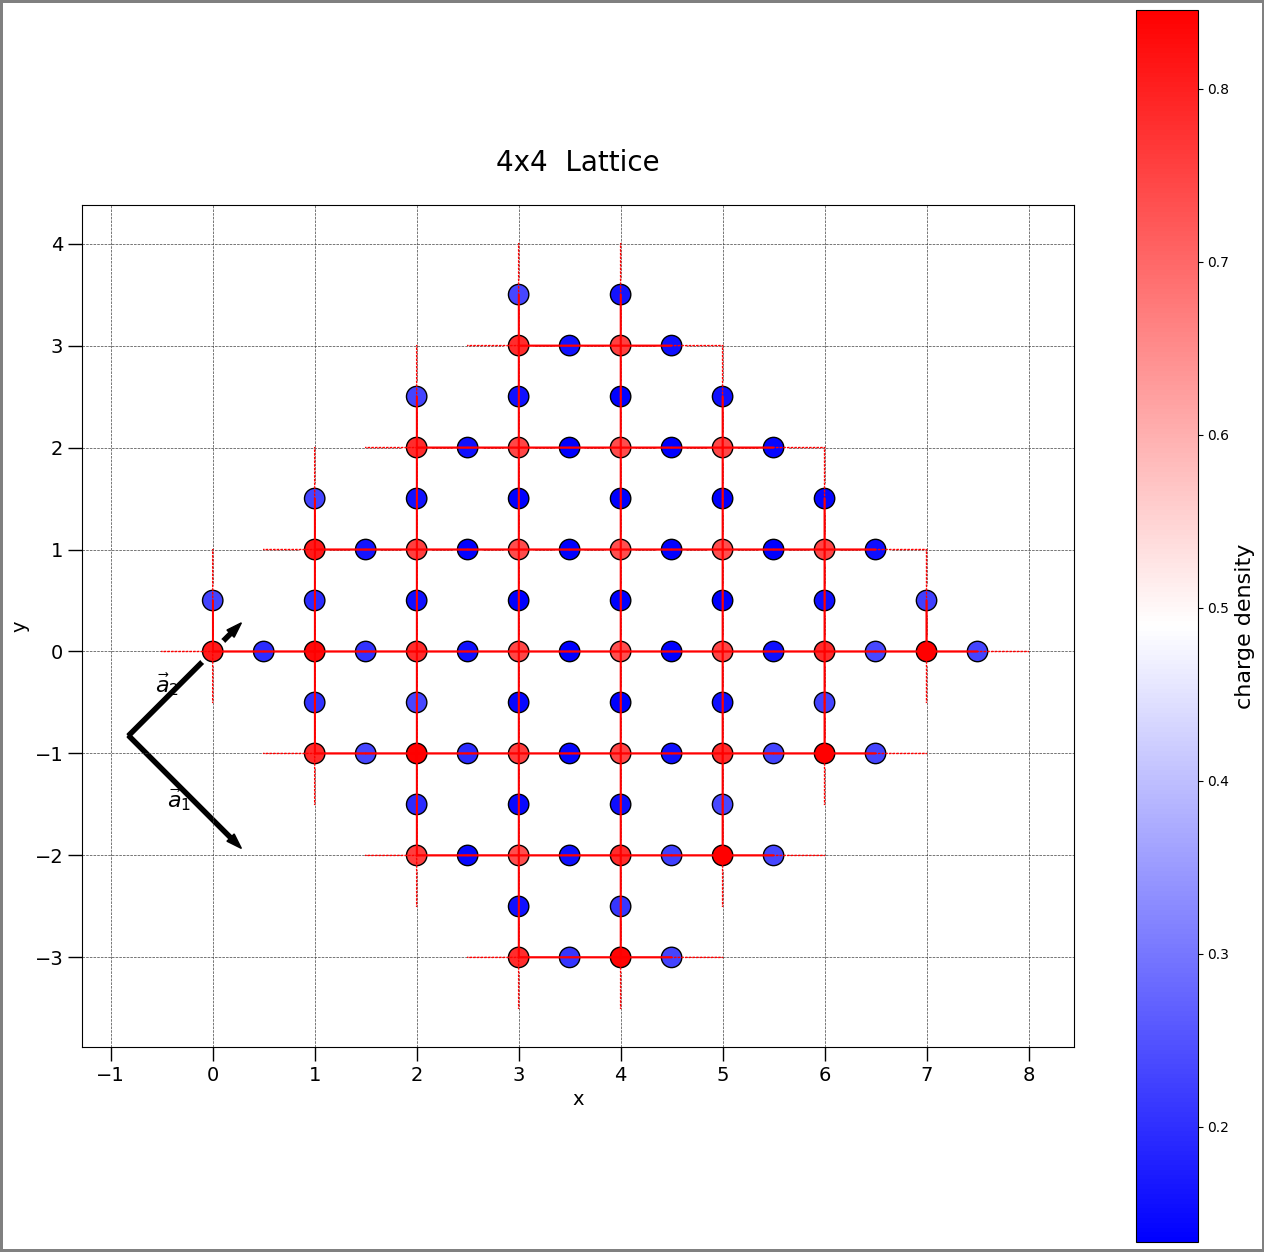

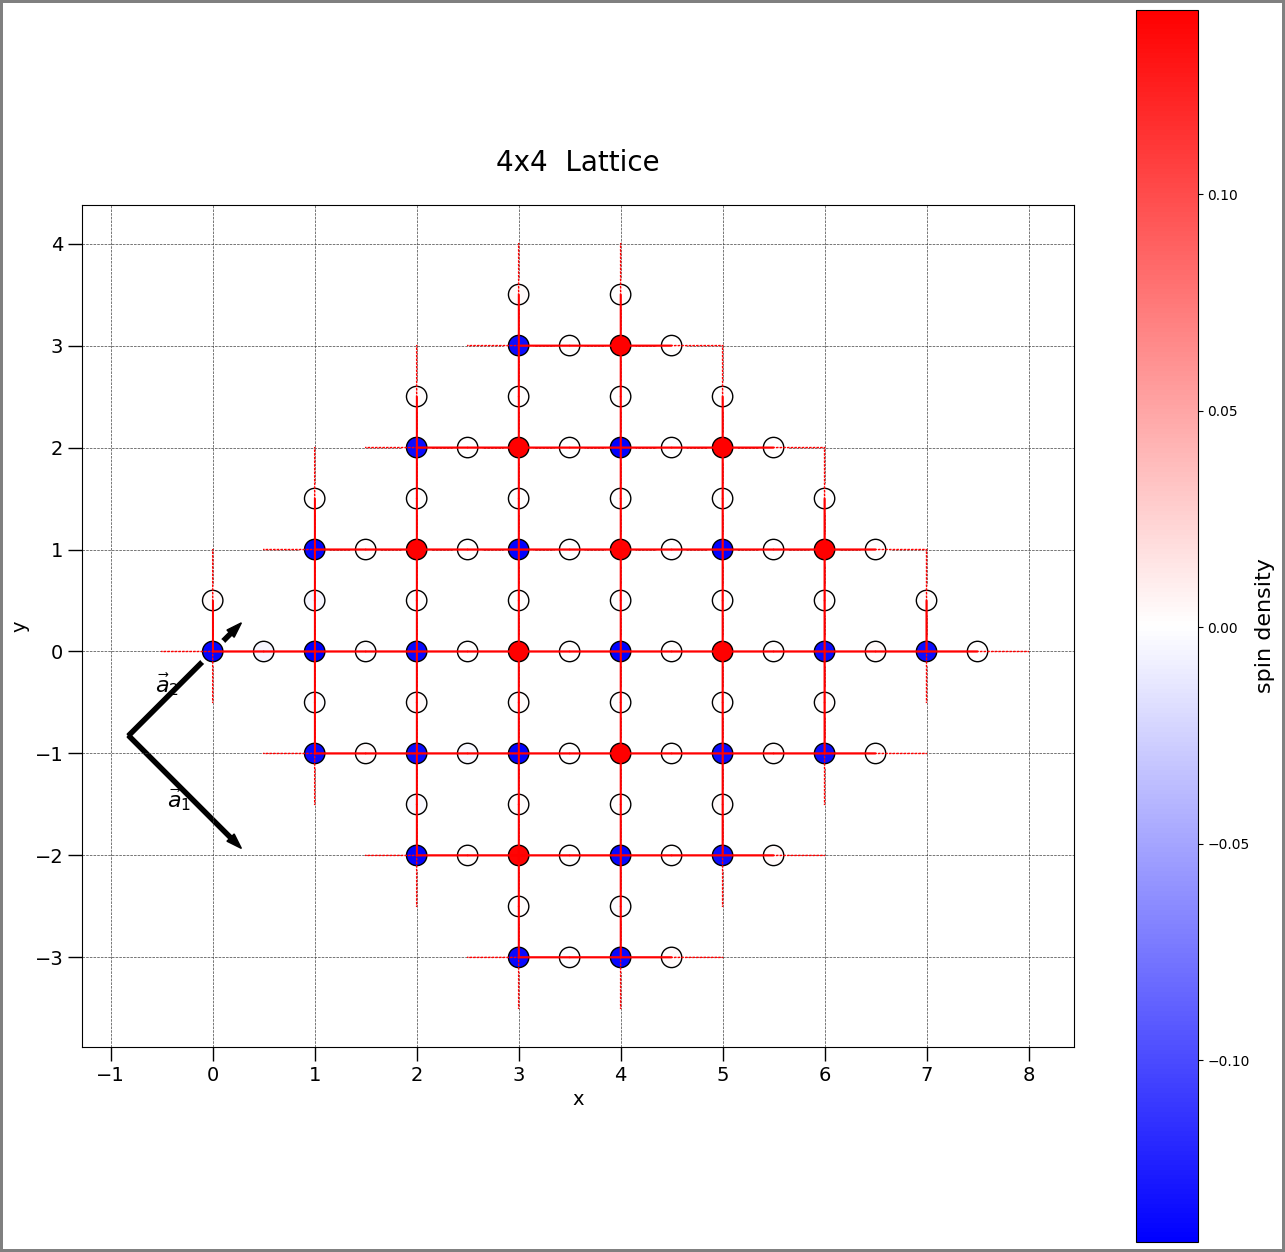

In [ ]:
"""
This is a benchmarking script, so we'll keep things basic
"""
import numpy as np
import h5py as h5

import afqmctools.systems.lattice as lat
import afqmctools.hamiltonian.model.director as ham
import afqmctools.utils.io as io
import afqmctools.utils.visualize as vis
from afqmctools.wavefunction.free_electron import free_electron
from afqmctools.wavefunction.common import modified_gram_schmidt

from afqmctools.hamiltonian.model.builder import HamiltonianBuilder
from afqmctools.hamiltonian.model.ham_class import HamiltonianComponent,SpinSymm

import faulthandler; faulthandler.enable()

import scipy.sparse as sps

import jax.numpy as jnp
import jax

import jax
# Set the default device to CPU
#jax.config.update('jax_platform_name', 'cpu')

print("JAX devices : ",jax.devices())


import matplotlib.pyplot as plt
import pdb

#### Some input params ######
recompute = True
show_lattice_before = True

annealing_steps = 10
annealing_amplitude = 0.01

L = (4,4)
Cu_per_cell = 2
h = 1/8

#expected HF energy
Ehf_ref = -313.792

#############################

# this is Nelec = (h+1) * Ncell where Ncell is the number of primitive cells
# BUT, be careful. the tilted lattice has two primitive cells per unit cell!
nelec_total = (h+1) * L[0] * L[1] * Cu_per_cell

assert nelec_total % 2 == 0, "must have even number of electrons"

nelec = (int(nelec_total//2),int(nelec_total//2))

print(f" ==== Emery model run parameters ==== ")
print(f"   - hole doping, h = {h}")
print(f"   - nelectrons = {nelec}")


def make_emery(lattice, show_mats=False):
    """
    """

    # 2. define / build the model
    tdp = 1.2
    tpp = 0.7
    epsilon_d = -7.6
    epsilon_p = -3.2
    Ud = 8.4
    Up = 2.0

    x_hat = np.array([1.0,0.0])
    y_hat = np.array([0.0,1.0])

    r_x_minus_y_hat = (1/np.sqrt(2))*np.array([1.0,-1.0])  # \hat{r}_{x-y} = \hat{x} - \hat{y}
    r_xy_hat = (1/np.sqrt(2))*np.array([1.0,1.0])         # \hat{r}_{x+y} = \hat{x} + \hat{y}

    lattice = lattice

    hopping_shape = (lattice.N_sites, lattice.N_sites)

    hopping = np.zeros(hopping_shape)

    for pair in lattice.get_nth_neighbors(n=1):
        i,j = pair.i,pair.j
        if j <= i:
            continue

        # NOTE: hard code the hopping phase between sublattices for now.
        tdp_pq = tdp*np.array(
            [[0.0,1.0,1.0],
            [-1.0,0.0,1.0],
            [-1.0,1.0,0.0]]
        ) # starting on sublattice from row, ending on sublattece from column
        p = pair.i % 3 # sublattice of i
        q = pair.j % 3 # sublattice of j

        # TODO: save origin and destination sublattice to NeighborPair object
        if np.dot(pair.r_relative,x_hat) > 0 or np.dot(pair.r_relative,-y_hat) > 0:
            hopping[i,j] = -tdp_pq[p,q]
        elif np.dot(pair.r_relative,-x_hat) > 0 or np.dot(pair.r_relative,y_hat) > 0:
            hopping[i,j] = tdp_pq[p,q]
        else:
            raise ValueError(f"Unexpected relative distance for nearest neighbors. {pair.r_relative}")

    for pair in lattice.get_nth_neighbors(n=2):
        i,j = pair.i,pair.j
        if j <= i:
            continue

        if np.dot(pair.r_relative,r_x_minus_y_hat) != 0.0:
            hopping[i,j] = tpp
        elif np.dot(pair.r_relative,r_xy_hat) != 0.0:
            hopping[i,j] = -tpp
        else:
            raise ValueError(f"Unexpected relative distance for next-nearest neighbors. {pair.r_relative}")


    # add in the j<=i part of the hopping matrix
    hopping = hopping + hopping.T.conj()


    # add in on-site energies
    U = np.zeros((lattice.N_sites,lattice.N_sites))
    for i in range(lattice.N_sites):
        if i % 3 == 0:
            hopping[i,i] = epsilon_d
            U[i,i] = Ud
        elif i % 3 == 1 or i % 3 == 2:
            hopping[i,i] = epsilon_p
            U[i,i] = Up

    if show_mats:
        plt.matshow(hopping.real)
        plt.title("Hopping matrix")
        plt.colorbar()
        plt.grid(True)
        plt.show()

    if show_mats:
        plt.matshow(U)
        plt.title("U matrix")
        plt.colorbar()
        plt.grid(True)
        plt.show()

    hopping = np.block(
        [[hopping,np.zeros(hopping_shape)]
        ,[np.zeros(hopping_shape),hopping]]
    )

    # 3. save the Hamiltonian
    builder = HamiltonianBuilder(lattice=lattice)
    hopping = sps.csr_matrix(hopping)
    custom_one_body = HamiltonianComponent(
        csr_array=hopping,
        model_type='one_body',
        spin_symm=SpinSymm.NONCOLLINEAR
    )

    # manually add the custom term
    builder.hamiltonian["tij"] = custom_one_body
    custom_hubbard = HamiltonianComponent(
        csr_array=U,
        model_type='hubbard_u',
        hst_type='discrete_spin'
    )
    builder.hamiltonian["Uij"] = custom_hubbard
    builder.finalize()

    hamiltonian = builder.hamiltonian

    io.write_model_hamiltonian(
        hamiltonian=hamiltonian,
        fname="afqmc.h5",
        nelec=nelec
    )

    return hamiltonian

# 1. define the lattice
basis = [ np.array(delta) for delta in [(0,0),(0.5,0),(0,0.5),(1.0,0),(1.5,0),(1.0,0.5)] ]

lattice = lat.CustomLattice(
    L=(4,4),
    a1=np.array((1.0,-1.0)),
    a2=np.array((1.0,1.0)),
    basis=basis,
    axis1_boundary=lat.PBCBoundary,
    axis2_boundary=lat.PBCBoundary,
)

if show_lattice_before:
    vis.plot_lattice(
        lattice,
        show_labels=True,
        show_lattice_vecs=False,
        title="Lieb lattice"
    )

hamiltonian = make_emery(lattice,show_mats=True)


# for initial guess - we need another H with a small twist!
THETA_X = 1/np.sqrt(592560607) # 592560607 is prime
THETA_Y = 1/np.sqrt(47603)     # 47603 is prime
twist = np.array((THETA_X,THETA_Y))

lattice_wt_twist = lat.CustomLattice(
    L=(4,4),
    a1=np.array((1.0,-1.0)),
    a2=np.array((1.0,1.0)),
    basis=basis,
    twist=twist
)

hamiltonian2 = make_emery(lattice_wt_twist)

wfn,spin_symm = free_electron(
    source=hamiltonian2,
    nelec=nelec,
    lattice=lattice,
    spin_symm=SpinSymm.NONCOLLINEAR
)

# add noise to the initial guess
wfn = (wfn[0],wfn[1] + annealing_amplitude*np.random.randn(*wfn[1].shape))

# 4. run autohf
from autohf import lattice_hf, AutoHFHamiltonian
best_E_final = None
for a in range(annealing_steps):
    print(f"Annealing step {a}")

    slater_det = wfn[1][0]

    hf_settings = dict(
        ansatz = 'SD',#'SD_Rot',
        steps = 500, #numSteps = 500,
        #output = f"ghf_wfn_step_{a}.h5",
        nelec = nelec,
        batch_size = 20, #numTrials = 20,
        #seed = 42,
        measure_spin = False,
        noncollinear =  True,
        gpu = False,
        state0_scale = 1.0e-3,
    )

    results, functions = lattice_hf(
        hamiltonian=AutoHFHamiltonian(hamiltonian),
        lattice=lattice,
        settings=hf_settings,
        jaxoptargs=dict(tol=1e-8),
        initial_guess=slater_det,
    )



    # now look at the density
    makeRDMs = functions['makeRDMs']
    state = results['state']
    rdm = makeRDMs(state)

    with h5.File("dev_checkpoint.h5","w") as f:
        f.create_dataset(f"rdm_{a}",data=rdm)

    # get a wavefunction for the next annealing step
    orbitals = results['orbitals'][0]

    slater_det = np.array(orbitals[:,:sum(nelec)])
    # orthonormalize!
    slater_det = modified_gram_schmidt(slater_det)
    slater_det = slater_det + annealing_amplitude*np.random.randn(*slater_det.shape)

    wfn = (wfn[0],[slater_det])

    L = lattice.L

    # noncollinear
    M = lattice.N_sites
    new_shape = (L[0],L[1],lattice.nb)
    rho_up = rdm[:M,:M].diagonal().reshape(new_shape)
    rho_down = rdm[M:,M:].diagonal().reshape(new_shape)

    rho_charge = rho_up + rho_down
    rho_spin = 0.5*(rho_up - rho_down)



    if best_E_final is None:
        best_E_final = results['E']
        best_rho_charge = rho_charge
        best_rho_spin = rho_spin
        best_rdm = rdm

    if results['E'] < best_E_final:
        print("Found a better energy: ",results['E'])
        best_E_final = results['E']
        best_rho_charge = rho_charge
        best_rho_spin = rho_spin
        best_rdm = rdm

    if recompute:
        with h5.File("dev_checkpoint.h5","a") as f:
            f.create_dataset("E",data=best_E_final)
            f.create_dataset(f"best_rho_charge",data=best_rho_charge)
            f.create_dataset(f"best_rho_spin",data=best_rho_spin)


print(f"\nBest Energy = {best_E_final} t")
print(f"            = {best_E_final / (L[0] * L[1] * Cu_per_cell)} t / Cu site\n\n")

rdm = best_rdm
rho_charge = best_rho_charge
rho_spin = best_rho_spin

print(f"Integrated charge: {rho_charge.real.sum()}")

print(f" mean charge density: {rho_charge.real.mean()} +/- {np.std(rho_charge.real)}")
print(f" mean spin density: {rho_spin.real.mean()} +/- {np.std(rho_spin.real)}")

Cu_inds =  jnp.array([i*lattice.nb for i in range(lattice.N_sites//lattice.nb)])
Opx_inds = jnp.array([i*lattice.nb+1 for i in range(lattice.N_sites//lattice.nb)])
Opy_inds = jnp.array([i*lattice.nb+2 for i in range(lattice.N_sites//lattice.nb)])

Cu_density_up = rdm[:M,:M].diagonal()[Cu_inds]
Opx_density_up = rdm[:M,:M].diagonal()[Opx_inds]
Opy_density_up = rdm[:M,:M].diagonal()[Opy_inds]

Cu_density_down  = rdm[M:,M:].diagonal()[Cu_inds]
Opx_density_down = rdm[M:,M:].diagonal()[Opx_inds]
Opy_density_down = rdm[M:,M:].diagonal()[Opy_inds]

Cu_density = Cu_density_up + Cu_density_down
Opx_density = Opx_density_up + Opx_density_down
Opy_density = Opy_density_up + Opy_density_down

print(f"For Cu sublattice: mean charge density: {np.mean(Cu_density.real)} +/- {np.std(Cu_density.real)}")
print(f"For O px sublattice: mean charge density: {np.mean(Opx_density.real)} +/- {np.std(Opx_density.real)}")
print(f"For O py sublattice: mean charge density: {np.mean(Opy_density.real)} +/- {np.std(Opy_density.real)}")


if True:
    vis.plot_lattice(
        lattice,
        density=rho_charge.real,
        density_label="charge density",
        cmap = 'bwr',
        show_labels=False,
        save="charge.png"
    )

    vis.plot_lattice(
        lattice,
        density=rho_spin.real,
        density_label="spin density",
        cmap = 'bwr',
        show_labels=False,
        save="spin.png"
    )
